# VITON Dataset Model Training
This notebook demonstrates a simple U-Net training pipeline on the VITON dataset. We will train a model to generate the person's image `train_img` given the target clothing `train_color`.


## 1. Imports


In [6]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


## 2. Preprocessing & Dataset


In [7]:
class VITONDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        self.color_dir = os.path.join(root_dir, 'train_color')
        self.img_dir = os.path.join(root_dir, 'train_img')
        
        # Get valid matched pairs inside both dirs
        self.valid_pairs = []
        for color_name in sorted(os.listdir(self.color_dir)):
            if color_name.endswith('.jpg') or color_name.endswith('.png'):
                # In VITON naming, clothing is often *_1.jpg and person image is *_0.jpg
                person_name = color_name.replace('_1.jpg', '_0.jpg').replace('_1.png', '_0.png')
                if os.path.exists(os.path.join(self.img_dir, person_name)):
                    self.valid_pairs.append((color_name, person_name))

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, idx):
        color_name, person_name = self.valid_pairs[idx]
        
        color_path = os.path.join(self.color_dir, color_name)
        img_path = os.path.join(self.img_dir, person_name)
        
        # Load images
        color_image = Image.open(color_path).convert('RGB')
        target_image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            color_image = self.transform(color_image)
            target_image = self.transform(target_image)
            
        return {'cloth': color_image, 'person': target_image}

# Define transforms
data_transforms = transforms.Compose([
    transforms.Resize((256, 192)), # Common size for Try-On tasks
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Initialize Dataset and DataLoader
dataset_path = '../../data/VITON_Dataset/ACGPN_TrainData' # Relative path from ml/VITON_Training
viton_dataset = VITONDataset(root_dir=dataset_path, transform=data_transforms)
dataloader = DataLoader(viton_dataset, batch_size=4, shuffle=True, num_workers=0)

print(f"Total training pairs: {len(viton_dataset)}")


Total training pairs: 14221


## 3. Dataset Visualizations


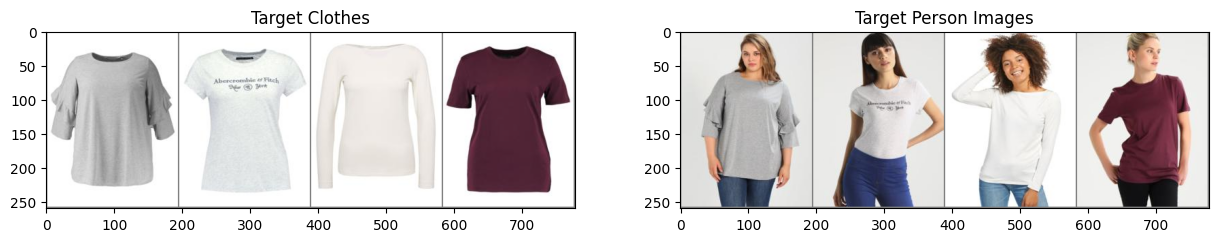

In [8]:
# Visualization
def imshow(img, title=None):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)

# Get a batch of training data
batch = next(iter(dataloader))
cloth_batch = batch['cloth']
person_batch = batch['person']

# Show images
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
imshow(utils.make_grid(cloth_batch), title='Target Clothes')
plt.subplot(1, 2, 2)
imshow(utils.make_grid(person_batch), title='Target Person Images')
plt.show()


## 4. Model Architecture (U-Net)


In [9]:
class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True, dropout=0.0):
        super(UNetDown, self).__init__()
        layers = [nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super(UNetUp, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class SimpleUNet(nn.Module):
    def __init__(self):
        super(SimpleUNet, self).__init__()
        # Downsampling
        self.down1 = UNetDown(3, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)

        # Upsampling
        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 256)
        self.up4 = UNetUp(512, 128)
        self.up5 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, 3, 4, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)

        u1 = self.up1(d6, d5)
        u2 = self.up2(u1, d4)
        u3 = self.up3(u2, d3)
        u4 = self.up4(u3, d2)
        u5 = self.up5(u4, d1)

        return self.final(u5)

model = SimpleUNet().to(device)
print('Model initialized!')


Model initialized!


## 5. Model Training


In [10]:
# Hyperparameters
learning_rate = 0.0002
num_epochs = 5

# Loss function and optimizer
criterion = nn.L1Loss() # Pixel-wise loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.5, 0.999))

print("Starting Training Loop...")
training_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    for i, batch in enumerate(dataloader):
        cloth = batch['cloth'].to(device)
        person_real = batch['person'].to(device)
        
        # Forward pass
        person_fake = model(cloth)
        
        # Calculate loss
        loss = criterion(person_fake, person_real)
        
        # Backward pass & optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        if (i+1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}")
            
    avg_loss = epoch_loss / len(dataloader)
    training_losses.append(avg_loss)
    print(f"==> Epoch {epoch+1} Average Loss: {avg_loss:.4f}")

print("Training finished!")



Starting Training Loop...
Epoch [1/5], Step [50/3556], Loss: 0.2746
Epoch [1/5], Step [100/3556], Loss: 0.3298
Epoch [1/5], Step [150/3556], Loss: 0.3051
Epoch [1/5], Step [200/3556], Loss: 0.2833
Epoch [1/5], Step [250/3556], Loss: 0.2439
Epoch [1/5], Step [300/3556], Loss: 0.2876
Epoch [1/5], Step [350/3556], Loss: 0.3026
Epoch [1/5], Step [400/3556], Loss: 0.2556
Epoch [1/5], Step [450/3556], Loss: 0.2754
Epoch [1/5], Step [500/3556], Loss: 0.2878
Epoch [1/5], Step [550/3556], Loss: 0.2670
Epoch [1/5], Step [600/3556], Loss: 0.2398
Epoch [1/5], Step [650/3556], Loss: 0.2484
Epoch [1/5], Step [700/3556], Loss: 0.2229
Epoch [1/5], Step [750/3556], Loss: 0.2622
Epoch [1/5], Step [800/3556], Loss: 0.3024
Epoch [1/5], Step [850/3556], Loss: 0.3394
Epoch [1/5], Step [900/3556], Loss: 0.2576
Epoch [1/5], Step [950/3556], Loss: 0.2858
Epoch [1/5], Step [1000/3556], Loss: 0.2363
Epoch [1/5], Step [1050/3556], Loss: 0.3133
Epoch [1/5], Step [1100/3556], Loss: 0.3290
Epoch [1/5], Step [1150/35

## 6. Save Model


Model saved to viton_unet_model.pth


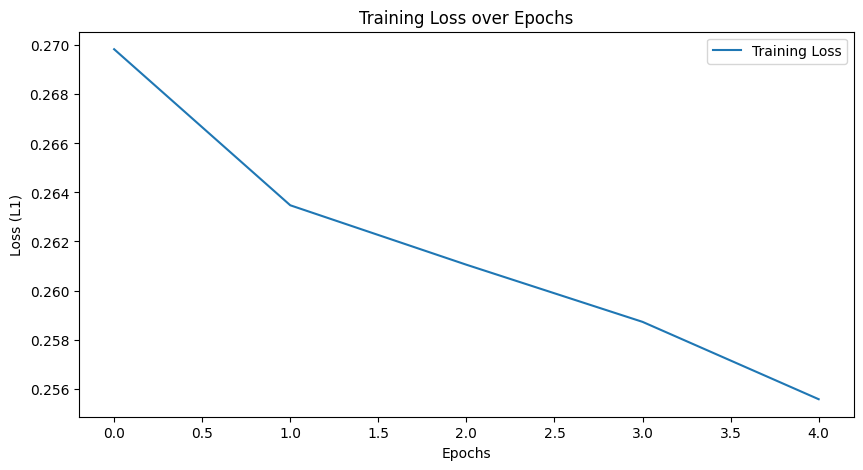

In [11]:
# Save the model state dict
torch.save(model.state_dict(), 'viton_unet_model.pth')
print("Model saved to viton_unet_model.pth")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(training_losses, label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (L1)')
plt.legend()
plt.show()